In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [5]:
df = pd.read_csv("outputs/cleaned_data.csv")

df.head()

,date,store_id,product_id,category,region,inventory_level,units_sold,units_ordered,demand_forecast,price,discount,weather_condition,holiday_promotion,competitor_pricing,seasonality,revenue
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn,4254.50
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn,9451.50
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer,1819.35
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn,1995.92
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer,1030.96


In [8]:
df.columns

Index(['date', 'store_id', 'product_id', 'category', 'region',
       'inventory_level', 'units_sold', 'units_ordered', 'demand_forecast',
       'price', 'discount', 'weather_condition', 'holiday_promotion',
       'competitor_pricing', 'seasonality', 'revenue'],
      dtype='str')

In [9]:
df["forecast_error"] = (
    df["units_sold"]
    -
    df["demand_forecast"]
)

In [10]:
df["absolute_error"] = (
    df["forecast_error"]
    .abs()
)

In [11]:
df["forecast_accuracy"] = (
    1 -
    (
        df["absolute_error"]
        /
        (
            df["units_sold"] + 1
        )
    )
) * 100

In [12]:
df[
    [
        "units_sold",
        "demand_forecast",
        "forecast_error",
        "forecast_accuracy"
    ]
].head()

,units_sold,demand_forecast,forecast_error,forecast_accuracy
0,127,135.47,-8.47,93.382812
1,150,144.04,5.96,96.052980
2,65,74.02,-9.02,86.333333
3,61,62.18,-1.18,98.096774
4,14,9.26,4.74,68.400000


In [13]:
df["forecast_accuracy"].mean()

np.float64(75.73219287399883)

In [14]:
category_accuracy = (
    df.groupby("category")
    ["forecast_accuracy"]
    .mean()
    .sort_values(ascending=False)
)

category_accuracy

category
Electronics    76.590981
Furniture      76.081992
Clothing       75.882133
Toys           75.103140
Groceries      75.007124
Name: forecast_accuracy, dtype: float64

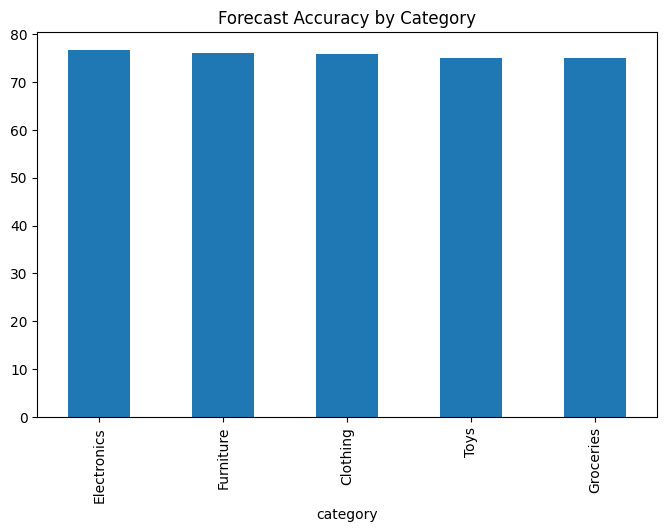

In [15]:
category_accuracy.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Forecast Accuracy by Category")

plt.show()

In [16]:
product_error = (
    df.groupby("product_id")
    ["absolute_error"]
    .mean()
    .sort_values(ascending=False)
)

product_error.head(10)

product_id
P0013    8.493193
P0003    8.467089
P0018    8.436164
P0004    8.417111
P0019    8.400460
P0017    8.380919
P0012    8.380328
P0007    8.356755
P0001    8.333212
P0011    8.331524
Name: absolute_error, dtype: float64

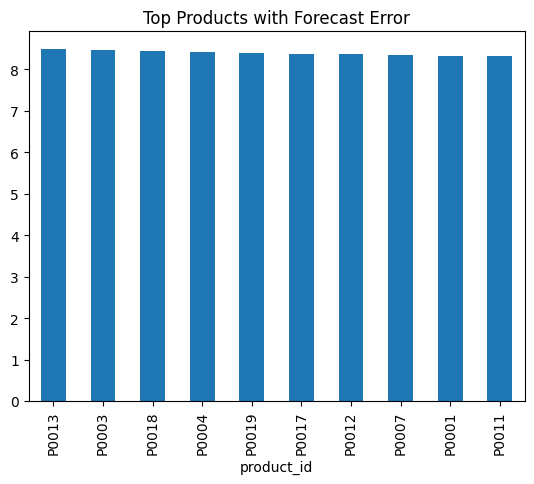

In [17]:
product_error.head(10).plot(
    kind="bar"
)

plt.title("Top Products with Forecast Error")

plt.show()

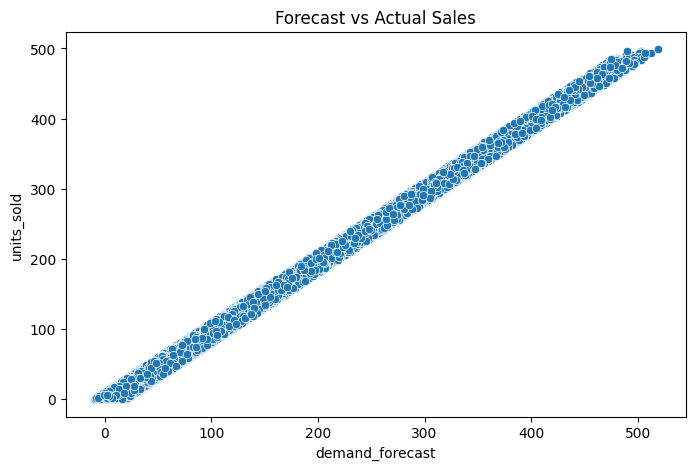

In [18]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="demand_forecast",
    y="units_sold"
)

plt.title("Forecast vs Actual Sales")

plt.show()

In [19]:
df["demand_gap"] = (
    df["demand_forecast"]
    -
    df["units_sold"]
)

In [20]:
df["demand_gap"].describe()

count    73100.000000
mean         5.029850
std          8.660766
min        -10.000000
25%         -2.470000
50%          4.990000
75%         12.510000
max         20.000000
Name: demand_gap, dtype: float64

In [21]:
category_gap = (
    df.groupby("category")
    ["demand_gap"]
    .mean()
)

category_gap

category
Clothing       5.064314
Electronics    4.994777
Furniture      5.058610
Groceries      4.950691
Toys           5.080324
Name: demand_gap, dtype: float64

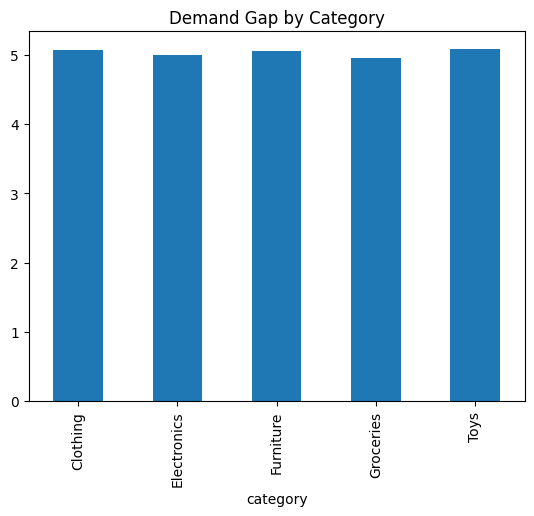

In [22]:
category_gap.plot(
    kind="bar"
)

plt.title("Demand Gap by Category")

plt.show()

In [23]:
df.to_csv(
    "outputs/demand_forecast_analysis.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully
